IMPORT LIBRARIES

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2                          # OpenCV — Session 3 tools
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier    # Session 9
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Image size Resize all images to a uniform size

IMG_SIZE = 64 # My chosen image size (64x64 pixels)

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [4]:
# Set dataset root path
DATASET_ROOT = 'C:/Users/Chinonso/Documents/MSc Data Science/SEMESTER 2/Image and Text Processing/ASSESSMENT 1/Plant disease classification'

# Discover classes from folder names 
CLASS_FOLDERS = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

print('=' * 60)
print('DATASET VERIFICATION REPORT')
print('=' * 60)
print(f'\nDataset root : {DATASET_ROOT}')
print(f'Classes found: {CLASS_FOLDERS}')

# Count images per class (JPG only)
class_counts = {}

for cls in CLASS_FOLDERS:
    folder = os.path.join(DATASET_ROOT, cls)
    imgs   = [f for f in os.listdir(folder)] #if f.lower().endswith('.jpg')
    class_counts[cls] = len(imgs)

total_images = sum(class_counts.values())

print(f'\nImage counts per class:')
for cls, cnt in class_counts.items():
    pct = cnt / total_images * 100
    print(f'  {cls:<30}: {cnt:>5,}  ({pct:.1f}%)')
print(f'  {"-"*48}')
print(f'  {"TOTAL":<30}: {total_images:>5,}  (100.0%)')

# Detect and report class imbalance
min_cls   = min(class_counts, key=class_counts.get)
max_cls   = max(class_counts, key=class_counts.get)
imbalance = class_counts[max_cls] / class_counts[min_cls]
print(f'\nClass imbalance ratio (max/min): {imbalance:.1f}x')
print(f'Minority class: {min_cls} ({class_counts[min_cls]} images)')
print('=' * 60)

DATASET VERIFICATION REPORT

Dataset root : C:/Users/Chinonso/Documents/MSc Data Science/SEMESTER 2/Image and Text Processing/ASSESSMENT 1/Plant disease classification
Classes found: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

Image counts per class:
  Potato___Early_blight         : 1,000  (46.5%)
  Potato___Late_blight          : 1,000  (46.5%)
  Potato___healthy              :   152  (7.1%)
  ------------------------------------------------
  TOTAL                         : 2,152  (100.0%)

Class imbalance ratio (max/min): 6.6x
Minority class: Potato___healthy (152 images)


In [5]:
images = []   # raw RGB images (H×W×3) for visualisation and HSV method
labels = []   # string class labels
paths  = []   # file paths for error analysis

print(f'Loading and resizing images to {IMG_SIZE}×{IMG_SIZE} px...')

for cls in CLASS_FOLDERS:
    folder   = os.path.join(DATASET_ROOT, cls)
    n_loaded = 0
    for fname in os.listdir(folder):
        if not fname.lower().endswith('.jpg'):   # JPG only
            continue
        fpath = os.path.join(folder, fname)
        img   = cv2.imread(fpath)                # loads as BGR
        if img is None:
            print(f'  Warning: could not read {fpath}')
            continue
        # Resizing with bilinear interpolation (cv2.INTER_LINEAR)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # convert to RGB for display
        images.append(img)
        labels.append(cls)
        paths.append(fpath)
        n_loaded += 1
    print(f'  {cls}: {n_loaded} images loaded')

images = np.array(images, dtype=np.uint8)
labels = np.array(labels)
paths  = np.array(paths)

# Encode labels to integers
le          = LabelEncoder()
labels_int  = le.fit_transform(labels)
class_names = le.classes_

short_names = ['Early blight', 'Late blight', 'Healthy']

print(f'\nTotal images loaded  : {len(images):,}')
print(f'Image array shape    : {images.shape}')

Loading and resizing images to 64×64 px...
  Potato___Early_blight: 1000 images loaded
  Potato___Late_blight: 1000 images loaded
  Potato___healthy: 152 images loaded

Total images loaded  : 2,152
Image array shape    : (2152, 64, 64, 3)


In [6]:

# Step 1: 70% train, 30% temp
X_train, X_temp, y_train, y_temp, p_train, p_temp = train_test_split(
    images, labels_int, paths,
    test_size=0.30, stratify=labels_int, random_state=RANDOM_STATE
)

# Step 2: split temp equally to 15% val, 15% test
X_val, X_test, y_val, y_test, p_val, p_test = train_test_split(
    X_temp, y_temp, p_temp,
    test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

def split_report(name, y_split):
    n   = len(y_split)
    pct = n / len(labels_int) * 100
    print(f'  {name:<12}: {n:>5,} images ({pct:4.1f}% of total)')
    for i, cn in enumerate(class_names):
        cnt   = (y_split == i).sum()
        print(f'    {short_names[i]:<18}: {cnt:>4,}  ({cnt/n*100:.1f}%)')

print('SPLIT VERIFICATION')
print('=' * 55)
split_report('Train',      y_train)
split_report('Validation', y_val)
split_report('Test',       y_test)
print('=' * 55)
print(f'Total: {len(y_train)+len(y_val)+len(y_test):,}  (should equal {len(labels_int):,})')

SPLIT VERIFICATION
  Train       : 1,506 images (70.0% of total)
    Early blight      :  700  (46.5%)
    Late blight       :  700  (46.5%)
    Healthy           :  106  (7.0%)
  Validation  :   323 images (15.0% of total)
    Early blight      :  150  (46.4%)
    Late blight       :  150  (46.4%)
    Healthy           :   23  (7.1%)
  Test        :   323 images (15.0% of total)
    Early blight      :  150  (46.4%)
    Late blight       :  150  (46.4%)
    Healthy           :   23  (7.1%)
Total: 2,152  (should equal 2,152)


In [7]:
# METHOD 1: HSV conversion (rule-based pipeline)
# Preprocessing function to convert RGB images to HSV colour space for the rule-based method
def to_hsv(rgb_img):
    """Convert a (H,W,3) RGB uint8 image to HSV."""
    bgr = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

print('\nPreprocessing complete.')


Preprocessing complete.


In [8]:
# HSV colour range definition
# OpenCV HSV: H=[0,180], S=[0,255], V=[0,255]

# Brown/yellow range — blight lesions
BROWN_LOWER = np.array([5,  60,  40],  dtype=np.uint8)
BROWN_UPPER = np.array([30, 255, 255], dtype=np.uint8)

# Green range — healthy leaf tissue
GREEN_LOWER = np.array([35, 40,  40],  dtype=np.uint8)
GREEN_UPPER = np.array([90, 255, 255], dtype=np.uint8)

# Dark range — late blight (low value = dark)
DARK_LOWER  = np.array([0,   0,   0],  dtype=np.uint8)
DARK_UPPER  = np.array([180, 255, 60], dtype=np.uint8)


def extract_colour_features(rgb_img):
    """
    Extract three colour ratio features from a single RGB image.
    Returns: (brown_ratio, green_ratio, dark_ratio)
    """
    hsv         = to_hsv(rgb_img)
    total_px    = rgb_img.shape[0] * rgb_img.shape[1]

    brown_mask  = cv2.inRange(hsv, BROWN_LOWER, BROWN_UPPER)
    green_mask  = cv2.inRange(hsv, GREEN_LOWER, GREEN_UPPER)
    dark_mask   = cv2.inRange(hsv, DARK_LOWER,  DARK_UPPER)

    brown_ratio = brown_mask.sum() / 255 / total_px
    green_ratio = green_mask.sum() / 255 / total_px
    dark_ratio  = dark_mask.sum()  / 255 / total_px

    return brown_ratio, green_ratio, dark_ratio


def rule_classify(brown_r, green_r, dark_r, t_brown, t_dark, t_green):
    """
    Apply the classification rule:
      - High dark ratio  → Late Blight (dark necrotic lesions dominate)
      - High brown ratio → Early Blight (brown/yellow lesions)
      - High green ratio → Healthy
    Class indices match LabelEncoder output (alphabetical order):
      0 = Early_blight, 1 = Healthy, 2 = Late_blight
    """
    # Map class names to int indices
    EARLY = np.where(class_names == 'Potato___Early_blight')[0][0]
    HLTHY = np.where(class_names == 'Potato___healthy')[0][0]
    LATE  = np.where(class_names == 'Potato___Late_blight')[0][0]

    if dark_r >= t_dark:
        return LATE
    elif brown_r >= t_brown:
        return EARLY
    else:
        return HLTHY


def rule_predict_batch(img_array, t_brown, t_dark, t_green):
    """Run the rule-based classifier on a batch of images."""
    preds = []
    for img in img_array:
        br, gr, dr = extract_colour_features(img)
        preds.append(rule_classify(br, gr, dr, t_brown, t_dark, t_green))
    return np.array(preds)


print('Rule-based classifier functions defined.')

Rule-based classifier functions defined.


In [9]:
# Threshold tuning on VALIDATION set
print('Tuning thresholds on validation set...')

brown_thresholds = np.arange(0.05, 0.40, 0.05)
dark_thresholds  = np.arange(0.05, 0.40, 0.05)
green_threshold  = 0.30    # fixed — green ratio threshold for healthy

best_f1       = -1
best_t_brown  = None
best_t_dark   = None
tuning_results = []

for t_b in brown_thresholds:
    for t_d in dark_thresholds:
        preds = rule_predict_batch(X_val, t_b, t_d, green_threshold)
        f1    = f1_score(y_val, preds, average='macro', zero_division=0)
        acc   = accuracy_score(y_val, preds)
        tuning_results.append({
            'brown_thresh': round(t_b, 3),
            'dark_thresh':  round(t_d, 3),
            'val_macro_f1': round(f1, 4),
            'val_accuracy': round(acc, 4)
        })
        if f1 > best_f1:
            best_f1      = f1
            best_t_brown = t_b
            best_t_dark  = t_d

tuning_df = pd.DataFrame(tuning_results).sort_values('val_macro_f1', ascending=False)

print('Top 10 threshold combinations (validation set):')
print(tuning_df.head(10).to_string(index=False))
print(f'\nBest brown threshold : {best_t_brown:.3f}')
print(f'Best dark threshold  : {best_t_dark:.3f}')
print(f'Best val macro-F1    : {best_f1:.4f}')

Tuning thresholds on validation set...
Top 10 threshold combinations (validation set):
 brown_thresh  dark_thresh  val_macro_f1  val_accuracy
         0.05         0.10        0.3739        0.3932
         0.10         0.10        0.3288        0.3344
         0.05         0.05        0.3271        0.3808
         0.05         0.15        0.3258        0.3870
         0.05         0.20        0.3027        0.3839
         0.05         0.25        0.2927        0.3777
         0.05         0.30        0.2927        0.3777
         0.05         0.35        0.2927        0.3777
         0.10         0.05        0.2901        0.3560
         0.15         0.10        0.2888        0.2848

Best brown threshold : 0.050
Best dark threshold  : 0.100
Best val macro-F1    : 0.3739


In [10]:
# Evaluate on TEST set with best thresholds
y_pred_rule = rule_predict_batch(X_test, best_t_brown, best_t_dark, green_threshold)

rb_accuracy  = accuracy_score(y_test, y_pred_rule)
rb_precision = precision_score(y_test, y_pred_rule, average='macro', zero_division=0)
rb_recall    = recall_score(y_test, y_pred_rule, average='macro', zero_division=0)
rb_f1        = f1_score(y_test, y_pred_rule, average='macro', zero_division=0)
rb_cm        = confusion_matrix(y_test, y_pred_rule)

print('RULE-BASED CLASSIFIER — TEST SET RESULTS')
print('=' * 50)
print(f'Accuracy       : {rb_accuracy:.4f}  ({rb_accuracy*100:.2f}%)')
print(f'Macro Precision: {rb_precision:.4f}')
print(f'Macro Recall   : {rb_recall:.4f}')
print(f'Macro F1       : {rb_f1:.4f}')
print('\nConfusion Matrix (rows=true, cols=predicted):')
print(pd.DataFrame(rb_cm, index=short_names, columns=short_names).to_string())
print('\nFull Classification Report:')
print(classification_report(y_test, y_pred_rule, target_names=short_names))

RULE-BASED CLASSIFIER — TEST SET RESULTS
Accuracy       : 0.3963  (39.63%)
Macro Precision: 0.4207
Macro Recall   : 0.5299
Macro F1       : 0.3770

Confusion Matrix (rows=true, cols=predicted):
              Early blight  Late blight  Healthy
Early blight            65           38       47
Late blight             44           43       63
Healthy                  0            3       20

Full Classification Report:
              precision    recall  f1-score   support

Early blight       0.60      0.43      0.50       150
 Late blight       0.51      0.29      0.37       150
     Healthy       0.15      0.87      0.26        23

    accuracy                           0.40       323
   macro avg       0.42      0.53      0.38       323
weighted avg       0.53      0.40      0.42       323



In [11]:
# Pixel normalisation + flattening (MLP pipeline)
def flatten_normalise(img_array):
    """
    Session 3: normalise pixels [0-255] → [0-1]
    Session 9: flatten (H, W, 3) → (H*W*3,) feature vector
    """
    n = img_array.shape[0]
    return img_array.reshape(n, -1).astype(np.float32) / 255.0

# Apply MLP pipeline to all splits
X_train_flat = flatten_normalise(X_train)
X_val_flat   = flatten_normalise(X_val)
X_test_flat  = flatten_normalise(X_test)

feature_dim = X_train_flat.shape[1]
print(f'Flattened feature vector length: {feature_dim:,}')
print(f'  = {IMG_SIZE} × {IMG_SIZE} × 3 channels = {IMG_SIZE*IMG_SIZE*3:,}  ✓')

# Session 9: StandardScaler for zero-mean, unit-variance normalisation
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_flat)   # fit on train only
X_val_sc    = scaler.transform(X_val_flat)          # apply to val
X_test_sc   = scaler.transform(X_test_flat)         # apply to test

print('\nPreprocessing complete.')
print(f'  X_train_sc shape: {X_train_sc.shape}')
print(f'  X_val_sc shape  : {X_val_sc.shape}')
print(f'  X_test_sc shape : {X_test_sc.shape}')

Flattened feature vector length: 12,288
  = 64 × 64 × 3 channels = 12,288  ✓

Preprocessing complete.
  X_train_sc shape: (1506, 12288)
  X_val_sc shape  : (323, 12288)
  X_test_sc shape : (323, 12288)


In [12]:
# Model selection: sweep hidden layer sizes on validation set
# evaluate on validation data, pick the best model.

hidden_configs = [
    (64,),
    (128,),
    (256,),
    (128, 64),
    (256, 128),
]

ms_results  = []
best_mlp_f1 = -1
best_config = None

print('MLP model selection (validation macro-F1):')
for cfg in hidden_configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg,
        activation='relu',
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1
    )
    mlp.fit(X_train_sc, y_train)
    val_preds = mlp.predict(X_val_sc)
    val_f1    = f1_score(y_val, val_preds, average='macro', zero_division=0)
    val_acc   = accuracy_score(y_val, val_preds)
    ms_results.append({'hidden_layers': str(cfg), 'val_macro_f1': round(val_f1, 4),
                       'val_accuracy': round(val_acc, 4)})
    marker = ' ← BEST' if val_f1 > best_mlp_f1 else ''
    print(f'  hidden={str(cfg):<15} | val F1={val_f1:.4f} | val Acc={val_acc:.4f}{marker}')
    if val_f1 > best_mlp_f1:
        best_mlp_f1 = val_f1
        best_config = cfg
        best_mlp    = mlp

print(f'\nSelected architecture: hidden_layer_sizes={best_config}')

MLP model selection (validation macro-F1):
  hidden=(64,)           | val F1=0.8328 | val Acc=0.9133 ← BEST
  hidden=(128,)          | val F1=0.8358 | val Acc=0.9102 ← BEST
  hidden=(256,)          | val F1=0.8616 | val Acc=0.9071 ← BEST
  hidden=(128, 64)       | val F1=0.8489 | val Acc=0.9164
  hidden=(256, 128)      | val F1=0.8815 | val Acc=0.9195 ← BEST

Selected architecture: hidden_layer_sizes=(256, 128)


In [13]:
# ── Evaluate best MLP on TEST set ─────────────────────────────────────────────
y_pred_ml = best_mlp.predict(X_test_sc)

ml_accuracy  = accuracy_score(y_test, y_pred_ml)
ml_precision = precision_score(y_test, y_pred_ml, average='macro', zero_division=0)
ml_recall    = recall_score(y_test, y_pred_ml, average='macro', zero_division=0)
ml_f1        = f1_score(y_test, y_pred_ml, average='macro', zero_division=0)
ml_cm        = confusion_matrix(y_test, y_pred_ml)

print('MLP CLASSIFIER — TEST SET RESULTS')
print('=' * 50)
print(f'Accuracy       : {ml_accuracy:.4f}  ({ml_accuracy*100:.2f}%)')
print(f'Macro Precision: {ml_precision:.4f}')
print(f'Macro Recall   : {ml_recall:.4f}')
print(f'Macro F1       : {ml_f1:.4f}')
print('\nConfusion Matrix (rows=true, cols=predicted):')
print(pd.DataFrame(ml_cm, index=short_names, columns=short_names).to_string())
print('\nFull Classification Report:')
print(classification_report(y_test, y_pred_ml, target_names=short_names))

MLP CLASSIFIER — TEST SET RESULTS
Accuracy       : 0.8916  (89.16%)
Macro Precision: 0.8878
Macro Recall   : 0.8118
Macro F1       : 0.8408

Confusion Matrix (rows=true, cols=predicted):
              Early blight  Late blight  Healthy
Early blight           145            5        0
Late blight             19          129        2
Healthy                  2            7       14

Full Classification Report:
              precision    recall  f1-score   support

Early blight       0.87      0.97      0.92       150
 Late blight       0.91      0.86      0.89       150
     Healthy       0.88      0.61      0.72        23

    accuracy                           0.89       323
   macro avg       0.89      0.81      0.84       323
weighted avg       0.89      0.89      0.89       323



TESTING BOTH MODEL PREDICTION ON RANDOM TEST IMAGES

MLP Prediction: Early blight  | Correct: True
Rule-Based Prediction: Healthy  | Correct: False


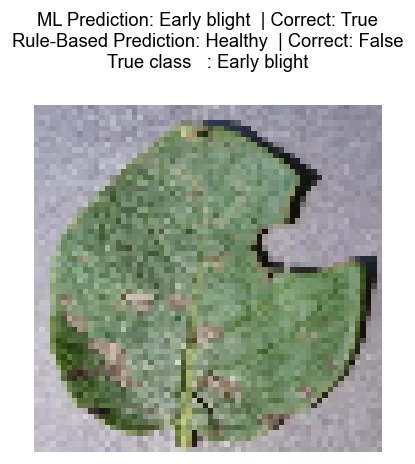

In [ ]:
import random

# Pick a random index from the test set
random_idx   = random.randint(0, len(X_test) - 1)
random_image = X_test[random_idx]        # raw RGB image (64×64×3)
true_label   = y_test[random_idx]        # integer class label (ground truth)
true_name    = short_names[true_label]   # human-readable class name

# Preprocess the image exactly as during training

# HSV hue extraction
brown_ratio, green_ratio, dark_ratio = extract_colour_features(random_image)

# Flatten (64×64×3) → (12288,) then apply the fitted StandardScaler
flat_image   = flatten_normalise(random_image.reshape(1, IMG_SIZE, IMG_SIZE, 3))  # (1, 12288)
scaled_image = scaler.transform(flat_image)   # same scaler fitted on training data


# Predict the raw image using both methods
pred_label_RB = rule_classify(brown_ratio, green_ratio, dark_ratio,
                           best_t_brown, best_t_dark, green_threshold)
pred_name_RB  = short_names[pred_label_RB]

pred_label_ML   = best_mlp.predict(scaled_image)[0]   # integer prediction
pred_name_ML    = short_names[pred_label_ML]              # human-readable prediction

# Check if prediction is correct
correct_ML = ('True' if pred_label_ML == true_label else 'False')
correct_RB = ('True' if pred_label_RB == true_label else 'False')

print(f'Rule-Based Prediction: {pred_name_RB}  | Correct: {correct_RB}')
print(f'MLP Prediction: {pred_name_ML}  | Correct: {correct_ML}')

# Display the image with prediction details
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(random_image)
ax.axis('off')

ax.set_title(
    f'Rule-Based Prediction: {pred_name_RB}  | Correct: {correct_RB}\n'
    f'ML Prediction: {pred_name_ML}  | Correct: {correct_ML}\n'
    f'True class   : {true_name}\n',
    fontsize=11,
    color='black',
    pad=10
)

plt.tight_layout()
plt.show()
